In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import re

In [2]:
FILE = "dataset_5.xlsx"

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.family"] = "DejaVu Sans"

''' Excel column letters (W, AD, J, R, AH, AZ). But when pandas reads an Excel file, it uses 0-based integer positions, not letters. This function converts "W" → 22, "AD" → 29, etc.'''
def col_idx(letter: str) -> int:
    idx = 0
    for ch in letter.upper():
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1


def to_num(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip().replace(",", ".").replace("\xa0", "").replace(" ", "")
    if s in ("", "...", "-", "–", "—", "n/a", "NA", "н/д"):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


AGGREGATES = {
    "российская федерация", "рф",
    "центральный федеральный округ",
    "северо-западный федеральный округ",
    "южный федеральный округ",
    "северо-кавказский федеральный округ",
    "приволжский федеральный округ",
    "уральский федеральный округ",
    "сибирский федеральный округ",
    "дальневосточный федеральный округ",
}

def is_aggregate(name: str) -> bool:
    if not isinstance(name, str):
        return False
    return name.strip().lower() in AGGREGATES


In [12]:
# ---------- Sheet 3: dynamics 2003-2024 ----------

df3 = pd.read_excel(FILE, sheet_name="3", header=3, skipfooter=4)
df3 = df3.dropna()
df3.columns = [str(c).strip() for c in df3.columns]


# ---------- Sheet 4: PC by region, 2024 in column W ----------
df4 = pd.read_excel(FILE, sheet_name="4", header=3)
df4.columns = [str(c).strip() for c in df4.columns]

# region name column = first column that contains non-numeric long strings
region_col4 = df4.columns[0]
pc_col4 = df4.columns[col_idx("W")]      # 2024 PC share

region_pc = df4[[region_col4, pc_col4]].copy()
region_pc.columns = ["region", "pc_share"]

region_pc["pc_share"] = region_pc["pc_share"].map(to_num)
region_pc = region_pc[~region_pc["region"].map(is_aggregate)]
region_pc = region_pc.dropna(subset=["pc_share"])




# ---------- Sheet 6: industries, 2024, columns J, R, AH, AZ ----------
df6 = pd.read_excel(FILE, sheet_name="6", header=5)
df6.columns = [str(c).strip() for c in df6.columns]

# column B = OKVED code (column index 1)
okved_col = df6.columns[1]
name_col6 = df6.columns[0] if len(df6.columns) > 2 else df6.columns[0]

ind = df6[[okved_col, name_col6,
           df6.columns[col_idx("J")],
           df6.columns[col_idx("R")],
           df6.columns[col_idx("AH")],
           df6.columns[col_idx("AZ")]]].copy()
ind.columns = ["okved", "industry", "pc", "servers", "internet", "website"]

# keep only top-level OKVED: single uppercase letter in column B
ind["okved"] = ind["okved"].astype(str).str.strip()
ind = ind[ind["okved"].str.fullmatch(r"[A-ZА-Я]", na=False)]

for c in ["pc", "servers", "internet", "website"]:
    ind[c] = ind[c].map(to_num)

ind = ind.dropna(subset=["pc", "servers", "internet", "website"]).reset_index(drop=True)



# ---------- Sheet 9: Internet by region, 2024 in column AD ----------
df9 = pd.read_excel(FILE, sheet_name="9", header=4)
df9.columns = [str(c).strip() for c in df9.columns]
region_col9 = df9.columns[0]
net_col9 = df9.columns[col_idx("AD")]     # 2024 Internet share

region_net = df9[[region_col9, net_col9]].copy()
region_net.columns = ["region", "net_share"]

region_net["net_share"] = region_net["net_share"].map(to_num)
region_net = region_net[~region_net["region"].map(is_aggregate)]
region_net = region_net.dropna(subset=["net_share"])


In [4]:
print("--------sheet 3--------------")
print(df3.to_string())

print("\n")

print("--------sheet 4--------------")
print(region_pc.head(10).to_string())

print("\n")

print("--------sheet 6--------------")
print(ind.to_string())

print("\n")

print("--------sheet 9--------------")
print(region_net.head(10).to_string())

print("\n")

--------sheet 3--------------
                                                                        Unnamed: 0    2003    2004    2005    2006    2007    2008    2009    2010    2011     2012     2013     2014     2015     2016     2017     2018     2019     2020     2021  2022 2)  2023 2)  2024 2)
0  Число персональных компьютеров \nв обследованных организациях - всего, тыс. шт.  4150.5  4558.3  5709.6  6684.0  7528.4  8267.3  8743.7  9288.1  9972.2  10807.5  11438.0  11740.8  11992.3  12422.1  12765.9  13256.1  13816.7  15791.4  17226.2  18080.7  18821.3  19818.7
2                                               имевшие доступ  к сети Интернет 3)   986.0  1218.8  1686.1  2232.0  2888.4  3411.5  3866.4  4553.3  5198.3   6066.5   6764.4   7277.6   7561.5   8117.9   8573.9   9090.4   9734.5  11120.8  12578.2  13106.8  13410.9        …
3               Поступило персональных компьютеров\nв отчетном году, тыс. шт.        656.2   743.8   984.2  1170.9  1257.9  1159.2   890.6   999.9  1251.6

# Часть I. 21 год цифровизации

In [5]:
# ============================================================
# 3. PART I — 21 years of digitalization (sheet 3)
# ============================================================
# Expect two rows: total PCs (thousand units) and PCs per 100 workers.
# The indicator-name column is the first column.

df3.columns = [re.sub(r"\s+\d+\)\s*$", "", str(c)).strip() for c in df3.columns]
year_cols = [c for c in df3.columns if re.fullmatch(r"(19|20)\d{2}", str(c).strip())]
print("Years detected:", year_cols[0], "->", year_cols[-1], "| n =", len(year_cols))

row_total  = df3.iloc[0]
row_per100 = df3.iloc[3]

def series_from_row(row, years):
    vals = [to_num(row[y]) for y in years]
    return pd.Series(vals, index=[int(y) for y in years], name="value")

s_total = series_from_row(row_total, year_cols)
s_per100 = series_from_row(row_per100, year_cols)

# --- Metrics ---
def metrics(s: pd.Series, label: str):
    s = s.dropna()
    first, last = s.iloc[0], s.iloc[-1]
    n_years = s.index[-1] - s.index[0]
    abs_chg = last - first
    ratio = last / first 
    cagr = (last / first) ** (1 / n_years) - 1 
    growth = s.pct_change() * 100
    max_growth_year = growth.idxmax()
    max_growth_val = growth.max()
    out = {
        "indicator": label,
        "first_year": s.index[0], "first_value": first,
        "last_year": s.index[-1],  "last_value": last,
        "abs_change": abs_chg,
        "ratio_x": ratio,
        "CAGR_%": cagr * 100,
        "max_annual_growth_%": max_growth_val,
        "max_growth_year": max_growth_year,
    }
    return out, growth

m_total, g_total = metrics(s_total, "PCs total (thousand)")
m_per100, g_per100 = metrics(s_per100, "PCs per 100 workers")

print(pd.DataFrame([m_total, m_per100]).to_string(index=False))

# Periods of acceleration / deceleration: 3-year rolling mean of growth
roll = g_total.rolling(3).mean()
accel = roll.diff()
print("\nSign of acceleration:\n", np.sign(accel).to_string())

Years detected: 2003 -> 2024 | n = 22
           indicator  first_year  first_value  last_year  last_value  abs_change  ratio_x   CAGR_%  max_annual_growth_%  max_growth_year
PCs total (thousand)        2003       4150.5       2024     19818.7     15668.2 4.775015 7.728877            25.257223             2005
 PCs per 100 workers        2003         18.0       2024        67.0        49.0 3.722222 6.458676            15.000000             2005

Sign of acceleration:
 2003    NaN
2004    NaN
2005    NaN
2006    NaN
2007    1.0
2008   -1.0
2009   -1.0
2010   -1.0
2011   -1.0
2012    1.0
2013   -1.0
2014   -1.0
2015   -1.0
2016   -1.0
2017    1.0
2018    1.0
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023   -1.0
2024   -1.0


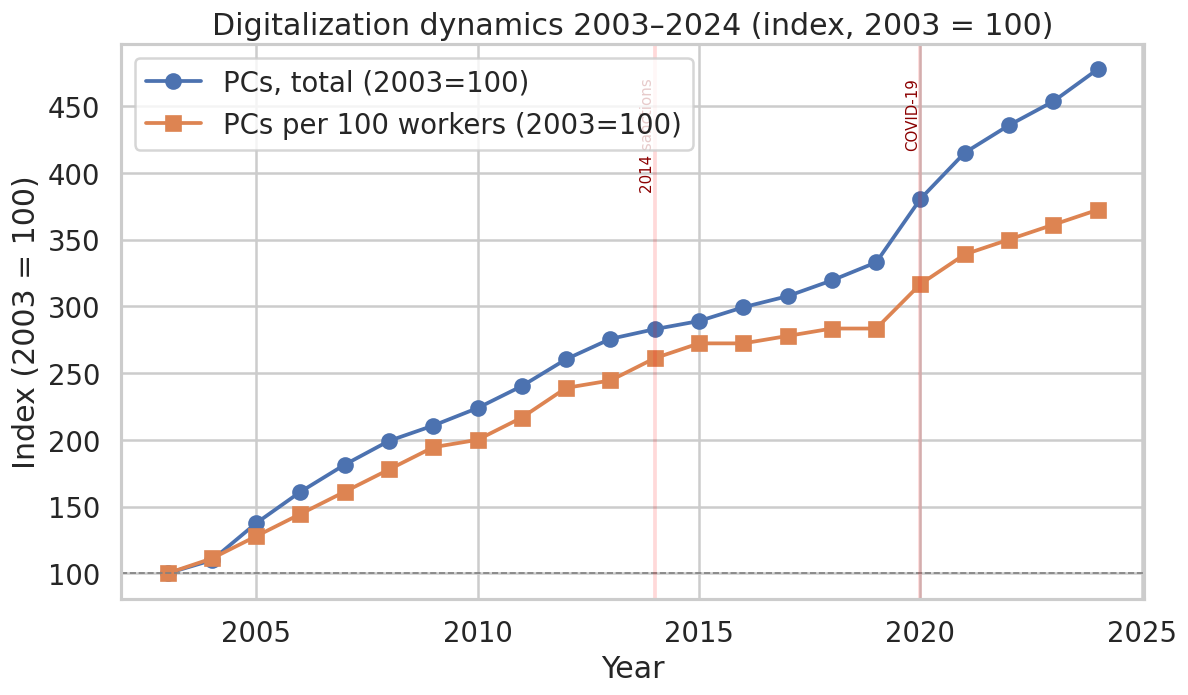

In [6]:
# ---------- Visualization 1: indexed to 2003=100 ----------
idx_total  = s_total  / s_total.dropna().iloc[0]  * 100
idx_per100 = s_per100 / s_per100.dropna().iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(idx_total.index,  idx_total.values,  marker="o", label="PCs, total (2003=100)")
ax.plot(idx_per100.index, idx_per100.values, marker="s", label="PCs per 100 workers (2003=100)")
ax.axhline(100, color="gray", lw=1, ls="--")

# Example annotations — adjust to the periods you find interesting
for yr, txt in [(2014, "2014 sanctions"), (2020, "COVID-19")]:
    if yr in idx_total.index:
        ax.axvline(yr, color="red", alpha=0.15)
        ax.text(yr, ax.get_ylim()[1]*0.95, txt, rotation=90,
                va="top", ha="right", fontsize=9, color="darkred")

ax.set_title("Digitalization dynamics 2003–2024 (index, 2003 = 100)")
ax.set_xlabel("Year"); ax.set_ylabel("Index (2003 = 100)")
ax.legend();plt.show()

# Часть II. Цифровая карта России — 2024

In [7]:
# ============================================================
# 4. PART II — regional scatter + correlation
# ============================================================
reg = pd.merge(region_pc, region_net, on="region", how="inner")
reg = reg.dropna()
print("Regions used:", len(reg))

desc = reg[["pc_share", "net_share"]].agg(
    ["mean", "median", "std", "min", "max"]
).T
print("\nDescriptive statistics:\n", desc.round(2).to_string())

r, p = stats.pearsonr(reg["pc_share"], reg["net_share"])
print(f"\nPearson r = {r:.3f}  (p = {p:.4g})")

Regions used: 86

Descriptive statistics:
             mean  median   std   min   max
pc_share   78.39    79.8  6.35  40.8  87.5
net_share  79.61    80.7  6.46  42.5  88.3

Pearson r = 0.952  (p = 4.579e-45)



Top-3 outlier regions:
                          region  pc_share  net_share       diff
Кабардино-Балкарская Республика      66.9       54.9 -13.580345
                      г. Москва      67.5       73.9   4.838309
                Республика Тыва      79.5       76.8  -3.888624


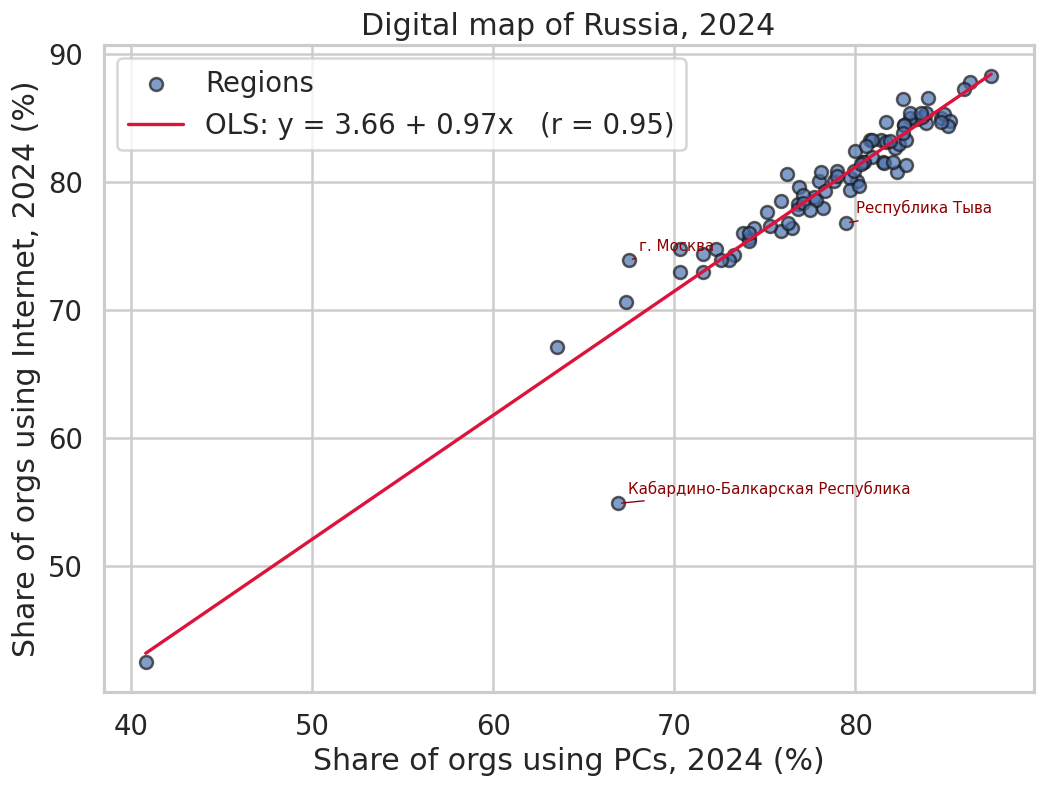

In [8]:
# ---------- Visualization 2: scatter + trend + outliers ----------
x = reg["pc_share"].values
y = reg["net_share"].values
slope, intercept, r_val, p_val, se = stats.linregress(x, y)
y_pred = intercept + slope * x
resid = y - y_pred

reg["diff"] = resid
outliers = reg.reindex(reg["diff"].abs().sort_values(ascending=False).index).head(3)
print("\nTop-3 outlier regions:\n", outliers[["region","pc_share","net_share","diff"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x, y, s=60, alpha=0.7, edgecolor="k", label="Regions")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, intercept + slope * xs, color="crimson", lw=2,
        label=f"OLS: y = {intercept:.2f} + {slope:.2f}x   (r = {r_val:.2f})")

for _, row in outliers.iterrows():
    ax.annotate(row["region"], (row["pc_share"], row["net_share"]),
                xytext=(6, 6), textcoords="offset points",
                fontsize=9, color="darkred",
                arrowprops=dict(arrowstyle="-", color="darkred", lw=0.8))

ax.set_xlabel("Share of orgs using PCs, 2024 (%)")
ax.set_ylabel("Share of orgs using Internet, 2024 (%)")
ax.set_title("Digital map of Russia, 2024")
ax.legend(); plt.show()

# Часть III. Цифровая зрелость отраслей


In [9]:
# ============================================================
# 5. PART III — industry correlation matrix
# ============================================================
ind_num = ind[["pc", "servers", "internet", "website"]].apply(pd.to_numeric, errors="coerce")
ind_num = ind_num.dropna()

corr = ind_num.corr(method="pearson")
print("\nCorrelation matrix:\n", corr.round(3).to_string())

# strongest / weakest off-diagonal pair
pairs = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i+1:]:
        pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda t: abs(t[2]))
print("\nWeakest pair:", pairs[0])
print("Strongest pair:", pairs[-1])


Correlation matrix:
              pc  servers  internet  website
pc        1.000    0.736     0.982    0.725
servers   0.736    1.000     0.701    0.511
internet  0.982    0.701     1.000    0.796
website   0.725    0.511     0.796    1.000

Weakest pair: ('servers', 'website', 0.5111826966427494)
Strongest pair: ('pc', 'internet', 0.9823162265217615)


In [ ]:
# z-scores on each indicator, then sum of |z| as "unusualness"
z = (ind_num - ind_num.mean()) / ind_num.std(ddof=1)
ind_z = ind.copy()
ind_z[["z_pc","z_srv","z_net","z_web"]] = z.values
ind_z["unusual"] = z.abs().sum(axis=1)
top_out = ind_z.sort_values("unusual", ascending=False).head(3)
print("\nMost unusual industries:\n", top_out[["industry","pc","servers","internet","website"]].to_string(index=False))


Most unusual industries:
                                                                              industry   pc  servers  internet  website
                                    Деятельность по операциям с недвижимым имуществом 63.2     28.6      67.4     27.3
Обеспечение элелектрической электроэнергией, газом и паром; кондиционирование воздуха 88.3     54.5      89.3     54.8
                                                                        Строительство 62.2     31.2      66.1     31.7


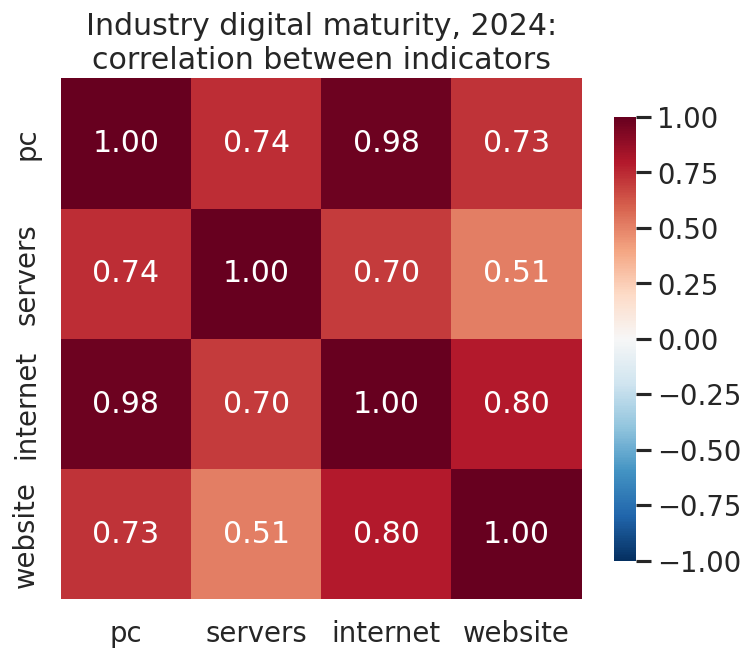

In [11]:
# ---------- Visualization 3: correlation heatmap ----------
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Industry digital maturity, 2024:\ncorrelation between indicators")
plt.show()